In [1]:
import os
import sys
import json
import re

import numpy as np
import pandas as pd
from collections import defaultdict

import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize

In [2]:
# Parent directory PATH
sys.path.append("..")

from utils.json import load_json, save_json
from data.dataset import json_keys, json_structure, extract_documents, extract_annotations, remove_punctuation, remove_punctuation_dataframe, group_labels, extract_annotations_and_split_documents

In [3]:
# Load the training data
file = "training.json"
path = "../data/raw/"
data = load_json(os.path.join(path, file))

Successfully loaded 254 documents from ../data/raw/training.json


In [4]:
print(f"Type of loaded data: {type(data)}")
print(f"Number of documents: {len(data)}")

Type of loaded data: <class 'list'>
Number of documents: 254


In [5]:
# Explore your JSON data
json_structure(data, max_depth=10)

root (list with 254 items)
    root[0] (dict with 3 keys)
        root[0].data (dict with 6 keys)
            root[0].data.cmbd (str): null
            root[0].data.id (str): 19026587
            root[0].data.docid (str): null
            root[0].data.page (str): null
            root[0].data.paragraph (str): null
            root[0].data.text (str):  nº historia clinica: ** *** *...
        root[0].annotations (list with 0 items)
        root[0].predictions (list with 1 items)
            root[0].predictions[0] (dict with 1 keys)
                root[0].predictions[0].result (list with 20 items)
                    root[0].predictions[0].result[0] (dict with 5 keys)
                        root[0].predictions[0].result[0].value (dict with 3 keys)
                            root[0].predictions[0].result[0].value.start (int): 449
                            root[0].predictions[0].result[0].value.end (int): 452
                            root[0].predictions[0].result[0].value.labels (l

In [6]:
# Get the JSON keys structure
structure = json_keys(data)

display(structure)

{'main_keys': ['annotations', 'data', 'predictions'],
 'data_keys': ['cmbd', 'docid', 'id', 'page', 'paragraph', 'text'],
 'prediction_keys': ['result'],
 'result_keys': ['from_name', 'id', 'to_name', 'type', 'value'],
 'value_keys': ['end', 'labels', 'start'],
 'label_types': ['NEG', 'NSCO', 'UNC', 'USCO']}

In [7]:
# Insights using the first document
record_first = data[0]

if isinstance(data, list):
    print(f"Type document: {type(data[0])}")
    print(f"Keys document: {structure['main_keys']}")
    print()

    for main_keys in record_first:
        print(f"Key: {main_keys}")
        print(f"Type: {type(record_first[main_keys])}")
        print(f"Length: {len(record_first[main_keys])}")
        print(f"Value: {record_first[main_keys]}")
        print()

        if "data" in main_keys:
            for k in record_first["data"].keys():
                print(f"\tKey: {k}")
                print(f"\tType: {type(record_first['data'][k])}")
                print(f"\tLength: {len(record_first['data'][k])}")
                print(f"\tValue: {record_first['data'][k]}")
                print()

Type document: <class 'dict'>
Keys document: ['annotations', 'data', 'predictions']

Key: data
Type: <class 'dict'>
Length: 6
Value: {'cmbd': 'null', 'id': '19026587', 'docid': 'null', 'page': 'null', 'paragraph': 'null', 'text': " nº historia clinica: ** *** *** nºepisodi: ******** sexe: home data de naixement: 16.05.1936 edat: 82 anys procedencia cex mateix hosp servei urologia data d'ingres 24.07.2018 data d'alta 25.07.2018 08:54:04 ates per ***************, *****; ****************, ****** informe d'alta d'hospitalitzacio motiu d'ingres paciente que ingresa de forma programada para realizacion de uretrotomia interna . antecedents alergia a penicilina y cloramfenicol . no habitos toxicos. antecedentes medicos: bloqueo auriculoventricular de primer grado hipertension arterial. diverticulosis extensa insuficiencia renal cronica colelitiasis antecedentes quirurgicos: exeresis de lesiones cutaneas con anestesia local protesis total de cadera cordectomia herniorrafia inguinal proces actua

In [8]:
extract_documents(data)

In [11]:
df_predictions = extract_annotations_and_split_documents(data)

449 452
449 452
452 468
452 468
844 856
287 299
863 872
306 315
872 895
315 338
998 1002
441 445
1002 1008
445 451
1539 1543
149 153
1543 1576
153 186
1643 1654
67 78
1654 1762
78 186
1902 1908
24 30
1908 1938
30 60
1989 1992
111 114
1992 2020
114 142
2153 2157
133 137
2157 2188
137 168
2219 2223
199 203
2223 2235
203 215
2410 2418
52 60
351 354
351 354
391 394
1 4
475 478
1 4
354 389
354 389
394 453
4 63
455 460
1 6
460 473
6 19
478 496
4 22
395 399
395 399
951 963
285 297
963 983
297 317
1009 1015
1 7
1015 1022
7 14
1062 1070
40 48
1186 1189
103 106
1189 1213
106 130
1213 1217
130 134
1217 1249
134 166
1523 1527
274 278
1527 1550
278 301
2388 2391
123 126
2391 2405
126 140
2717 2721
34 38
2721 2733
38 50
399 432
399 432
2189 2197
582 590
416 419
13 16
771 774
52 55
1067 1071
265 269
1445 1448
52 55
1498 1501
105 108
1501 1546
108 153
1890 1899
227 236
1899 1948
236 285
2097 2100
1 4
2837 2841
62 66
2911 2926
62 77
2926 2971
77 122
3176 3179
1 4
3399 3402
191 194
3485 3493
277 285
373

349 352
349 352
387 390
1 4
452 458
1 7
1015 1018
284 287
1042 1052
14 24
1167 1176
70 79
1529 1532
1 4
1642 1646
78 82
1790 1793
59 62
2585 2599
22 36
2599 2608
36 45
2709 2713
11 15
2713 2725
15 27
2982 2985
219 222
2985 2998
222 235
3894 3897
1 4
352 385
352 385
390 450
4 64
458 473
7 22
997 1013
266 282
1030 1040
2 12
1018 1027
287 296
1052 1096
24 68
1143 1165
46 68
1532 1563
4 35
1646 1654
82 90
1793 1809
62 78
2252 2294
1 43
2294 2302
43 51
3897 3970
4 77
389 392
389 392
392 416
392 416
557 560
1 4
577 580
1 4
906 909
85 88
922 925
1 4
974 977
1 4
1246 1250
17 21
1281 1285
52 56
1285 1289
56 60
1289 1293
60 64
1293 1297
64 68
1297 1301
68 72
2001 2004
1 4
2057 2061
21 25
2107 2110
1 4
2351 2354
113 116
560 575
4 19
580 599
4 23
909 920
88 99
925 941
4 20
977 1007
4 34
1230 1246
1 17
1277 1281
48 52
2004 2035
4 35
2061 2069
25 33
2110 2121
4 15
2354 2370
116 132
481 487
481 487
681 685
26 30
1080 1084
63 67
1151 1155
55 59
1699 1702
112 115
487 509
487 509
685 709
30 54
1084 1095

In [12]:
print(f"Extracted {len(df_predictions)} annotations")
display(df_predictions)

Extracted 9319 annotations


,doc_index,doc_id,result_id,start,end,label,text,line_number
0,0,19026587,ent0,448,451,NEG,no,19026587_0
1,0,19026587,ent1,451,467,NSCO,habitos toxicos.,19026587_0
19,0,19026587,ent19,51,59,NEG,"afebril,",19026587_11
2,0,19026587,ent2,286,298,NSCO,cistoscopia,19026587_2
3,0,19026587,ent3,305,314,NEG,negativa,19026587_2
...,...,...,...,...,...,...,...,...
9298,253,20339886,ent24,50,58,NEG,afebril,20339886_33
9299,253,20339886,ent25,36,48,UNC,sospecha de,20339886_35
9300,253,20339886,ent26,48,60,USCO,bacteriemia,20339886_35
9275,253,20339886,ent1,19,22,NEG,no,20339886_7


In [13]:
annotation_counts = df_predictions.groupby("doc_id").size().sort_values(ascending=False)

print()
print("Top 5 documents by annotation count:")
for doc_id, count in annotation_counts.head(10).items():
    print(f"Document {doc_id} has {count} annotations")


Top 5 documents by annotation count:
Document 19395557 has 216 annotations
Document 20321835 has 142 annotations
Document 19644561 has 135 annotations
Document 18876889 has 124 annotations
Document 19579840 has 115 annotations
Document 18703319 has 111 annotations
Document 19072809 has 110 annotations
Document 18888512 has 109 annotations
Document 18653570 has 100 annotations
Document 19374244 has 98 annotations


In [14]:
# Duplicated documents
true_counts = {}

# Count each unique document ID only once
for doc in data:
    doc_id = doc["data"]["id"]
    if doc_id in true_counts:
        true_counts[doc_id] += 1
    else:
        true_counts[doc_id] = 1

# Find actually duplicated IDs
actual_duplicates = {id: count for id, count in true_counts.items() if count > 1}

print(f"Number of documents: {len(data)}")
print(f"Number of unique document IDs: {len(true_counts)}")
print(f"Number of truly duplicated IDs: {len(actual_duplicates)}")
print()

if actual_duplicates:
    print("True duplicate document IDs:")
    for doc_id, count in actual_duplicates.items():
        print(f"ID {doc_id} appears {count} times")
else:
    print("No duplicate document IDs found")

Number of documents: 254
Number of unique document IDs: 247
Number of truly duplicated IDs: 2

True duplicate document IDs:
ID 18956072 appears 5 times
ID 18468396 appears 4 times


Label Distribution:
NEG: 4307 (46.22%)
NSCO: 4103 (44.03%)
UNC: 458 (4.91%)
USCO: 451 (4.84%)


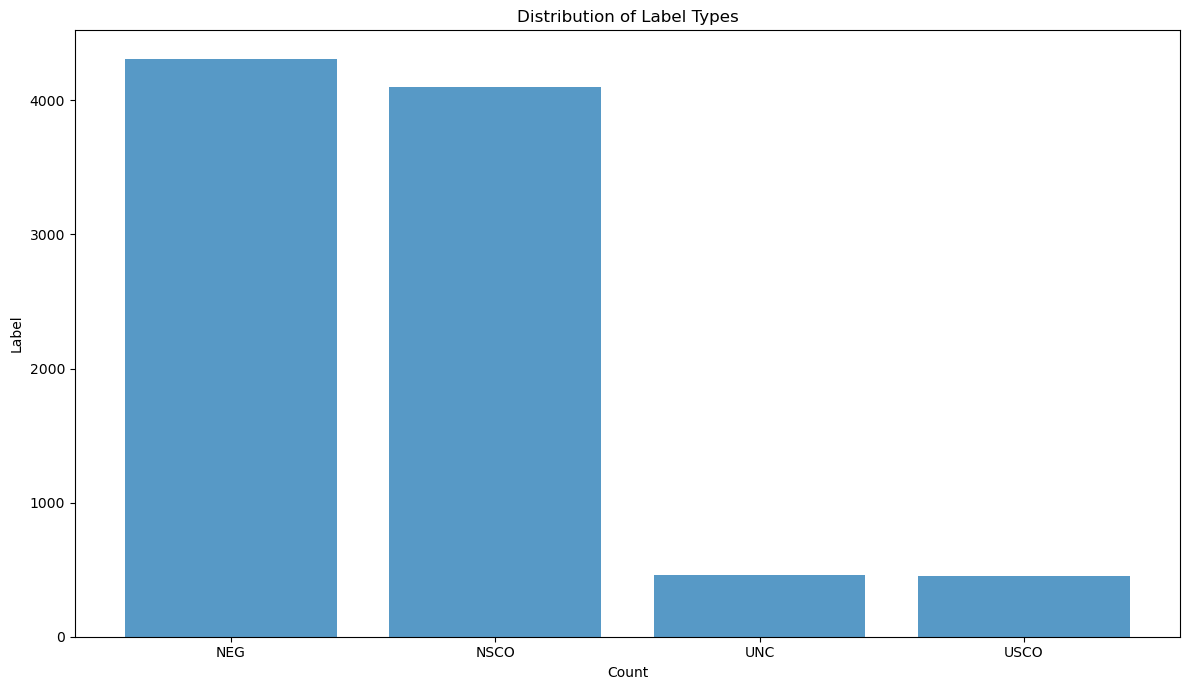

In [15]:
# Count the occurrences of each label
label_counts = df_predictions["label"].value_counts()

print("Label Distribution:")
for label, count in label_counts.items():
    print(f"{label}: {count} ({count/len(df_predictions)*100:.2f}%)")

labels = label_counts.index
counts = label_counts.values

# Plot the distribution using Matplotlib directly
plt.figure(figsize=(12, 7))
plt.bar(labels, counts, alpha=0.75)
plt.title("Distribution of Label Types")
plt.xlabel("Count")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

In [16]:
# we remove the punctuation from the scopes and add a new column to the dataframe with it
df_predictions = remove_punctuation_dataframe(df_predictions)

hola
no 
afebril,
negativa 
sin 
sin 
sin claras 
falsa 
no 
sin 
sin 
no 
no 
nega 
no 
sin 
ausencia de 
sin 
niega 
afebril,
no 
sin 
sin 
afebril,
no 
no 
no 
no 
aparente 
no 
sin 
sugestivos con 
no 
no 
tampoco 
sin 
podria 
no 
sin 
sin 
no 
podria 
sin 
no 
sin 
inespecificos
no 
sin
dudosa 
no 
posible 
dudosa 
probable 
afebril
sin 
afebril
no 
sin 
desaparicion de 
sin 
no 
no 
sin 
afebril.
sin 
sin 
no 
no 
no 
no
no 
no 
negativas
negativo 
negativo 
sin 
negativo
compatible con 
compatible con 
sin 
no 
sin 
no 
no 
no 
no 
no 
no 
sin 
no 
negativo
no 
no 
no 
no 
no 
no 
no 
negativos
no 
negativo 
negativo 
no 
negativos
sin 
no 
negativos
negativa
compatibles con 
sin 
afebril
sin 
sin 
sin 
sospecha de 
sin 
niega 
no 
niega 
niega 
sin 
afebril
no 
sin 
sugestiva de 
no 
no 
sin 
ex
sin 
sin 
no 
no 
sin 
no 
sin 
niega 
no 
niega 
sin 
sin 
sin 
sin 
sin 
no 
sin 
sin 
sin 
sin 
no 
sin 
niega 
no 
no 
no 
sin 
probables 
negativos
no 
no 
sin 
no 
compatibles co

In [17]:
# Common Negation Cues
neg_cues = df_predictions[df_predictions["label"] == "NEG"]["clean_text"].value_counts()
print("TOP Negation Cues: \n")
for cue, count in neg_cues.items():
    print(f"{cue}: {count}")

TOP Negation Cues: 

no: 1909
sin: 1423
negativo: 203
afebril: 188
niega: 136
negativos: 92
ausencia de: 64
negativa: 54
sense: 40
neg: 35
negativas: 24
asintomatica: 11
asintomatico: 10
ex: 9
inespecifico: 8
descarta: 8
falta de: 7
impide: 5
se retira: 4
ex-: 4
exfumador: 4
nega: 4
tampoco: 4
cede: 4
desaparicion de: 3
inespecificos: 3
inestabilidad: 3
retiro: 3
descartada: 3
negatividad de: 3
retirar: 3
negatiu: 3
excepto: 2
desorientacion: 2
niegan: 2
: 2
ausencia: 2
incapacidad para: 2
imposibilidad de: 2
se desestimo: 1
negaitvo: 1
suspendido: 1
desorientado: 1
ceden: 1
irregulares: 1
indetectable: 1
ex fumador: 1
imposibilidad: 1
negatividad: 1
se suspende: 1
en ninguna: 1
ninguno: 1
rechaza: 1
desaparecen: 1
atipicos: 1
arritmicos: 1
desaparicion del: 1
negatividad del: 1


In [18]:
# Common Uncertainty Cues
unc_cues = df_predictions[df_predictions["label"] == "UNC"]["clean_text"].value_counts()
print("TOP Uncertainty Cues: \n")
for cue, count in unc_cues.items():
    print(f"{cue}: {count}")

TOP Uncertainty Cues: 

compatible con: 58
probable: 54
sospecha de: 31
se orienta: 23
probablemente: 23
posible: 20
sugestiva de: 18
aparentemente: 17
compatibles con: 17
dudosa: 13
valorar: 12
sugestivo de: 10
podria: 10
parece: 9
sugestivos de: 9
sugestivas de: 7
aparente: 7
posiblemente: 5
vs: 5
dudoso: 5
sospechosa de: 4
podrian: 4
probables: 4
dudosamente: 4
sugiere: 4
no: 4
posibilidad de: 3
sin: 3
sospechosas de: 3
impresiona: 3
desconoce: 3
dudosos: 3
sugiriendo: 3
sospecha: 2
parecen: 2
sin poder descartar: 2
sugieren: 2
puede: 2
impresiona de: 2
compatible amb: 2
sin aparentes: 2
sin aparente: 2
orientan: 2
no parece: 2
aparentes: 2
sugieran: 2
ssospechosas de: 2
falsa: 1
sin claras: 1
sugestivos con: 1
desconocido: 1
pudieran: 1
orienta como: 1
se orientan: 1
plantea: 1
sin clara: 1
indiquen: 1
atribuida: 1
sugestiva como: 1
se desconoce: 1
poco porque: 1
sospechosos de: 1
interpreta: 1
sospitosa de: 1
al parecer: 1
no es posible descartar: 1
orienta: 1
posibles: 1
descarta

Average NSCO length: 24.36 characters
Average USCO length: 30.08 characters


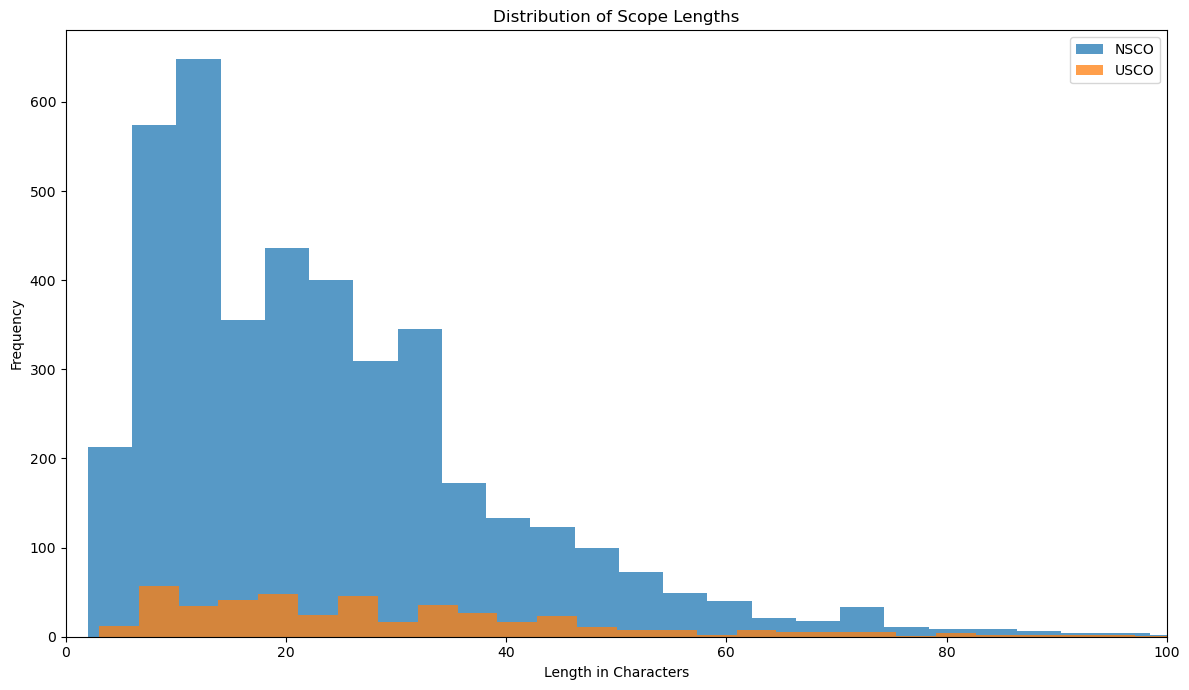

In [19]:
# Calculate scope lengths
df_predictions["text_length"] = df_predictions["text"].apply(len)

scope_labels = ["NSCO", "USCO"]

# Average Scope's 
for label in scope_labels:
    avg_len = df_predictions[df_predictions["label"] == label]["text_length"].mean()
    print(f"Average {label} length: {avg_len:.2f} characters")

# Plot scope length distributions by label type
plt.figure(figsize=(12, 7))
for label in scope_labels:
    scope_lengths = df_predictions[df_predictions["label"] == label]["text_length"]
    plt.hist(scope_lengths, bins=50, alpha=0.75, label=label)

plt.title("Distribution of Scope Lengths")
plt.xlabel("Length in Characters")
plt.ylabel("Frequency")
plt.legend()
plt.xlim(0, 100) # Limit to most common
plt.tight_layout()
plt.show()

### Group Scope with Cue

We can see the labels that are in each sentence and verify any outliers or error. If we see a clear pattern in these errors, we can change our line parser (the function that determines what is and what is not a punctuation period).

In [ ]:
def group_labels(df):
    # create a new column to store the scope for a CUE
    df["scope"] = None

    # group the Context and Cues that are consecutive
    list_rows = [row for row in df['line_number'].unique()]
    for row in list_rows:
        scope_count  = 0
        df_row = df[df['line_number'] == row]
        print(row)
        values_labels = df_row['label'].values
        print(values_labels)

        # outliers
        if row == '20103430_3': # this is very weird case that seems to be a mistake on the labeling
            continue

        match len(df_row):
            case 0:
                pass
            case 1:
                if df_row['label'].values[0] == 'NEG':
                    df.loc[df_row.index[0], 'scope'] = f"{row}_{scope_count}"
                elif df_row['label'].values[0] == 'UNC':
                    df.loc[df_row.index[0], 'scope'] = f"{row}_{scope_count}"
                else:
                    raise ValueError(f"Single label {df_row['label'].values[0]} in row {row}\ntext: {df_row['text'].values[0]}")
            case 2:
                if 'NEG' in values_labels and 'NSCO' in values_labels:
                    for index in df_row.index:
                        df.loc[index, 'scope'] = f"{row}_{scope_count}"
                    scope_count += 1
                elif 'UNC' in values_labels and 'USCO' in values_labels:
                    for index in df_row.index:
                        df.loc[index, 'scope'] = f"{row}_{scope_count}"
                    scope_count += 1
                elif 'NEG' in values_labels and 'UNC' in values_labels:
                    df.loc[0, 'scope'] = f"{row}_{scope_count}"
                    scope_count += 1
                    df.loc[1, 'scope'] = f"{row}_{scope_count}"
                    scope_count += 1
                elif values_labels[0] == 'NEG' and values_labels[1] == 'NEG':
                    df.loc[0, 'scope'] = f"{row}_{scope_count}"
                    scope_count += 1
                    df.loc[1, 'scope'] = f"{row}_{scope_count}"
                    scope_count += 1
                elif values_labels[0] == 'UNC' and values_labels[1] == 'UNC':
                    df.loc[0, 'scope'] = f"{row}_{scope_count}"
                    scope_count += 1
                    df.loc[1, 'scope'] = f"{row}_{scope_count}"
                    scope_count += 1
                else:
                    raise ValueError(f"Two labels {values_labels} in row {row}\ntext: {df_row['text'].values[0]}")


    return df

In [59]:
grouped_df = group_labels(df_predictions)
#grouped_df = transform_scope(grouped_df)

19026587_0
['NEG' 'NSCO']
19026587_11
['NEG']
19026587_2
['NSCO' 'NEG' 'NSCO' 'NEG' 'NSCO']
19026587_5
['NEG' 'NSCO']
19026587_6
['UNC' 'USCO']
19026587_8
['UNC' 'USCO' 'NEG' 'NSCO']
19026587_9
['NEG' 'NSCO' 'NEG' 'NSCO']
20331067_0
['NEG' 'NSCO']
20331067_1
['NEG' 'NSCO']
20331067_2
['NEG' 'NSCO']
20331067_3
['NEG' 'NSCO']
18843029_0
['NEG' 'NSCO']
18843029_1
['NEG' 'NSCO']
18843029_11
['NEG' 'NSCO']
18843029_2
['NEG' 'NSCO']
18843029_3
['NEG']
18843029_4
['NEG' 'NSCO' 'NEG' 'NSCO']
18843029_5
['NEG' 'NSCO']
18843029_7
['NEG']
18843029_8
['NEG' 'NSCO']
19754837_1
['NEG' 'NSCO']
19754837_11
['NEG' 'NSCO' 'NEG' 'NSCO']
19754837_12
['UNC' 'USCO']
19754837_14
['NEG' 'NSCO']
19754837_18
['NEG' 'NSCO']
19754837_19
['UNC' 'USCO']
19754837_22
['NEG' 'NSCO']
19754837_23
['NEG' 'NSCO' 'NEG' 'NSCO']
19754837_24
['NEG' 'NSCO' 'UNC' 'USCO']
19754837_25
['NEG' 'NSCO']
19754837_27
['NEG' 'NSCO']
19754837_29
['NEG' 'NSCO']
19754837_35
['NEG' 'NSCO' 'UNC' 'USCO']
19754837_36
['NEG' 'NSCO' 'NEG' 'NSCO'

ValueError: Single label NSCO in row 18468396_27
text: grapas 

In [22]:
grouped_df

,doc_index,doc_id,result_id,start,end,label,text,line_number,clean_text,text_length,scope
0,0,19026587,ent0,448,451,NEG,no,19026587_0,no,3,None
1,0,19026587,ent1,451,467,NSCO,habitos toxicos.,19026587_0,NaN,16,0
19,0,19026587,ent19,51,59,NEG,"afebril,",19026587_11,afebril,8,None
2,0,19026587,ent2,286,298,NSCO,cistoscopia,19026587_2,NaN,12,None
3,0,19026587,ent3,305,314,NEG,negativa,19026587_2,negativa,9,None
...,...,...,...,...,...,...,...,...,...,...,...
9298,253,20339886,ent24,50,58,NEG,afebril,20339886_33,afebril,8,None
9299,253,20339886,ent25,36,48,UNC,sospecha de,20339886_35,sospecha de,12,None
9300,253,20339886,ent26,48,60,USCO,bacteriemia,20339886_35,NaN,12,None
9275,253,20339886,ent1,19,22,NEG,no,20339886_7,no,3,None


### Save DataFrame

In [23]:
df_predictions

,doc_index,doc_id,result_id,start,end,label,text,line_number,clean_text,text_length,scope
0,0,19026587,ent0,448,451,NEG,no,19026587_0,no,3,None
1,0,19026587,ent1,451,467,NSCO,habitos toxicos.,19026587_0,NaN,16,0
19,0,19026587,ent19,51,59,NEG,"afebril,",19026587_11,afebril,8,None
2,0,19026587,ent2,286,298,NSCO,cistoscopia,19026587_2,NaN,12,None
3,0,19026587,ent3,305,314,NEG,negativa,19026587_2,negativa,9,None
...,...,...,...,...,...,...,...,...,...,...,...
9298,253,20339886,ent24,50,58,NEG,afebril,20339886_33,afebril,8,None
9299,253,20339886,ent25,36,48,UNC,sospecha de,20339886_35,sospecha de,12,None
9300,253,20339886,ent26,48,60,USCO,bacteriemia,20339886_35,NaN,12,None
9275,253,20339886,ent1,19,22,NEG,no,20339886_7,no,3,None


In [24]:
import pickle

pickle.dump(df_predictions, open("df_predictions.pkl", "wb"))